In [13]:
# Imports

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset

data = load_breast_cancer()
X = data.data
y = data.target

# train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# No. of Features

n_features = X_train.shape[1]

In [26]:
## Random Forest Predictions

# Random Forest Model

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)
forest_accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest Accuracy Score: {forest_accuracy}')

Random Forest Accuracy Score: 0.9649122807017544


In [14]:
# Fitness

def fitness(chromosomes):
  selected = np.where(np.array(chromosomes) == 1)[0]

  if len(selected) == 0:
    return 0

  model = RandomForestClassifier(n_estimators=100, random_state=42)
  model.fit(X_train[:, selected], y_train)
  y_preds = model.predict(X_test[:, selected])
  return accuracy_score(y_test, y_preds)

In [15]:
# Random Chromosome Function

def random_chromosome():
  return np.random.randint(0, 2, n_features)

POP_SIZE = 10
population = [random_chromosome() for _ in range(POP_SIZE)]

In [16]:
# Selecting Function

import random

def select(population):
  contenders = random.sample(population, 3)
  return max(contenders, key=fitness)

In [17]:
# Crossover Function

import random

def crossover(parent1, parent2):
  crossover_point = random.randint(1, len(parent1) - 1)
  child = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
  return child

In [24]:
# Mutate Function

import random

def mutate(individual, mutation_rate=0.1):
  mutated_individual = individual.copy()
  for i in range(len(mutated_individual)):
    if random.random() < mutation_rate:
      mutated_individual[i] = 1 - mutated_individual[i]
  return mutated_individual

In [25]:
# Main Body

GENERATIONS = 20
best_per_gene = []

for gen in range(GENERATIONS):
  new_population = []

  for i in range(POP_SIZE):
    parent1 = select(population)
    parent2 = select(population)
    child = crossover(parent1, parent2)
    child = mutate(child)
    new_population.append(child)

  population = new_population
  best_per_gene.append(max(population, key=fitness))

print(f'Generation: {gen+1}, Best Accuracy: {fitness(best_per_gene[-1])}')

Generation: 20, Best Accuracy: 1.0


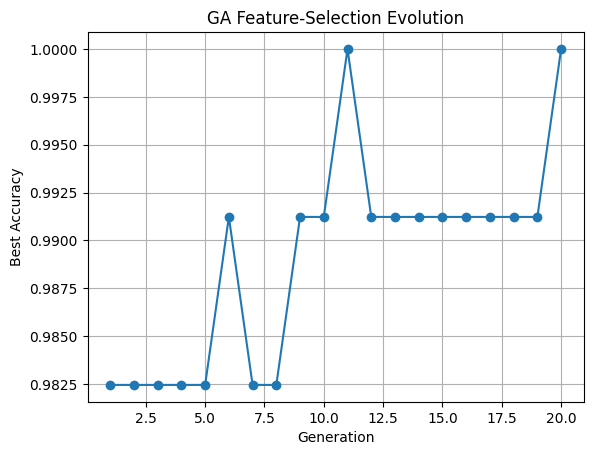

Selected 14 features of 30 features.
Final Accuracy:  1.0


In [27]:
# Plotting

import matplotlib.pyplot as plt

best_fitness_per_gene = [fitness(chromosome) for chromosome in best_per_gene]

plt.plot(range(1, GENERATIONS+1), best_fitness_per_gene, marker='o')
plt.title('GA Feature-Selection Evolution')
plt.xlabel('Generation')
plt.ylabel('Best Accuracy')
plt.grid(True)
plt.show()

best_chromosome = max(population, key=fitness)
selected_features = np.where(best_chromosome == 1)[0]

print(f'Selected', len(selected_features), 'features of', n_features , 'features.')
print(f'Final Accuracy: ', fitness(best_chromosome))